#Seasonal Agriculture Performance Analysis
VOIS AICTE Batch 1 (2026-2027) — Major Project

Student Name: Sandip Mahato

College Name: Visva-Bharati University

AICTE STU ID:STU69cacc29e97901774898217

**Problem:** Does agricultural performance (yield, revenue, profit) differ across seasons (Kharif, Rabi, Zaid)?

**Objective:** Clean the data, compare seasons, test relationships, and give evidence-based recommendations.

## 1. Import Libraries
Loads all required packages and sets shared style/colour settings.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os, warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
SEASON_ORDER = ["Kharif", "Rabi", "Zaid"]
PALETTE = {"Kharif": "#2C5F2D", "Rabi": "#B85042", "Zaid": "#E7A93C"}
os.makedirs("outputs", exist_ok=True)

def save(fig, name):
    fig.savefig(f"outputs/{name}", bbox_inches="tight", dpi=150)

## 2. Load Data
Reads the CSV and previews the first 5 rows and shape (4,000 rows x 28 columns).

In [ ]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print(df.shape)
df.head()

(4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 3. Data Understanding
Column types, missing-value counts, and duplicate check — all printed as plain text.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


In [ ]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


## 4. Data Cleaning
- Missing values (Rainfall, Soil Moisture, Yield ~1% each) → filled with Season+Crop median.
- No duplicates. No invalid negative values.
- Yield is right-skewed because Sugarcane yields are naturally much higher — kept as valid data.

In [ ]:
for col in ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]:
    df[col] = df.groupby(["Season", "Crop"])[col].transform(lambda x: x.fillna(x.median()))
print("Missing after cleaning:", df.isnull().sum().sum())

Missing after cleaning: 0


## 5. Data Preparation
Orders the Season category and adds a simple profitable/not-profitable flag.

In [ ]:
df["Season"] = pd.Categorical(df["Season"], categories=SEASON_ORDER, ordered=True)
df["Profit_Margin_pct"] = (df["Profit_INR"] / df["Revenue_INR"].replace(0, np.nan)) * 100
df["Is_Profitable"] = df["Profit_INR"] > 0

## 6. Overall EDA
Summary statistics table for the main numeric columns.

In [ ]:
df[["Yield_Tonnes_Ha","Revenue_INR","Profit_INR","Rainfall_mm"]].describe().round(2)

,Yield_Tonnes_Ha,Revenue_INR,Profit_INR,Rainfall_mm
count,4000.00,4000.00,4000.00,4000.00
mean,5.27,637860.05,111556.46,600.72
std,13.34,636974.71,545081.89,288.42
min,0.30,6107.00,-1019223.00,80.00
25%,1.05,207517.25,-148731.75,370.42
50%,1.74,456830.50,3673.00,581.00
75%,2.84,836874.75,216187.75,835.95
max,101.44,5080900.00,4345421.00,1395.20


**Farm Records by Season**
Bar chart of how many records fall in each season (Kharif has the most).

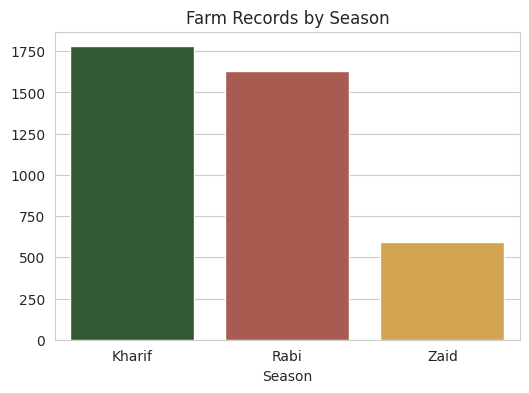

In [ ]:
season_counts = df["Season"].value_counts().reindex(SEASON_ORDER)
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x=season_counts.index, y=season_counts.values, order=SEASON_ORDER, palette=PALETTE, ax=ax)
ax.set_title("Farm Records by Season")
save(fig, "farm_records_by_season.png"); plt.show()

## 7. Seasonal Summary
Table of mean values for key metrics, grouped by season.

In [ ]:
df.groupby("Season", observed=True)[[
    "Yield_Tonnes_Ha","Revenue_INR","Total_Cost_INR","Profit_INR",
    "Water_Used_m3","Rainfall_mm","Avg_Temperature_C","Fertilizer_kg_ha","Disease_Pest_Risk_pct"
]].mean().round(2)

,Yield_Tonnes_Ha,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Rainfall_mm,Avg_Temperature_C,Fertilizer_kg_ha,Disease_Pest_Risk_pct
Season,,,,,,,,,
Kharif,5.63,710719.06,531804.41,178914.65,6102.20,852.10,28.45,187.08,54.47
Rabi,5.09,601526.05,513836.58,87689.47,5846.99,435.95,23.49,185.41,40.48
Zaid,4.64,519171.90,543976.73,-24804.82,6419.89,299.16,31.04,184.64,38.22


## 8. Analytical Questions

**Q1. Yield by Season**
Bar chart comparing average yield (t/ha) across the three seasons.

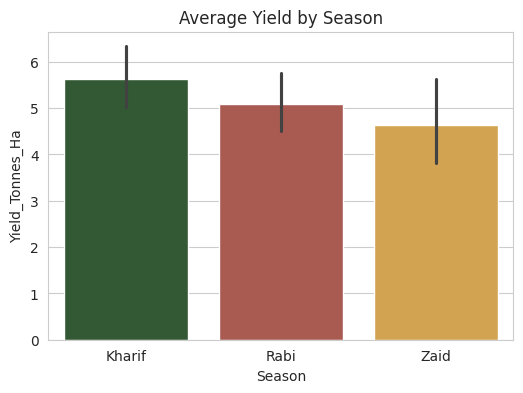

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x="Season", y="Yield_Tonnes_Ha", data=df, order=SEASON_ORDER, palette=PALETTE, errorbar=("ci",95), ax=ax)
ax.set_title("Average Yield by Season")
save(fig, "q1_yield.png"); plt.show()

*Kharif > Rabi > Zaid.*

**Q1b. Production by Season**
Bar chart of average total production (tonnes) per season.

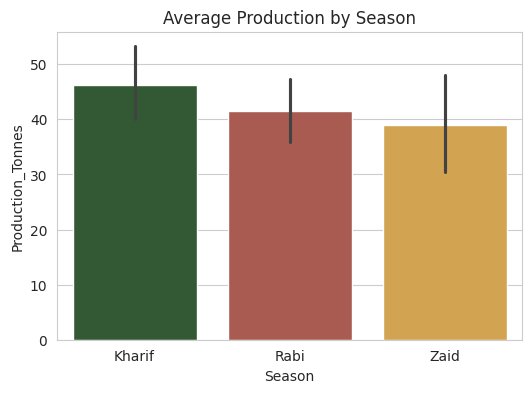

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x="Season", y="Production_Tonnes", data=df, order=SEASON_ORDER, palette=PALETTE, errorbar=("ci",95), ax=ax)
ax.set_title("Average Production by Season")
save(fig, "q1b_production.png"); plt.show()

*Same seasonal ordering as yield.*

**Q2. Profit by Season**
Boxplot of profit distribution per season, with a zero-profit reference line.

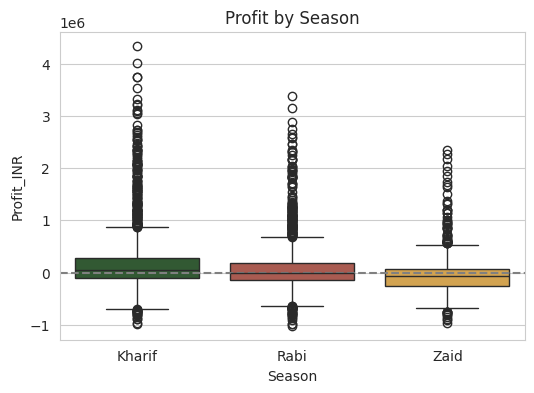

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(x="Season", y="Profit_INR", data=df, order=SEASON_ORDER, palette=PALETTE, ax=ax)
ax.axhline(0, color="grey", ls="--")
ax.set_title("Profit by Season")
save(fig, "q2_profit.png"); plt.show()

*Zaid's average profit is negative.*

**Q2b. Revenue vs Cost by Season**
Grouped bar chart comparing average revenue and cost side by side for each season.

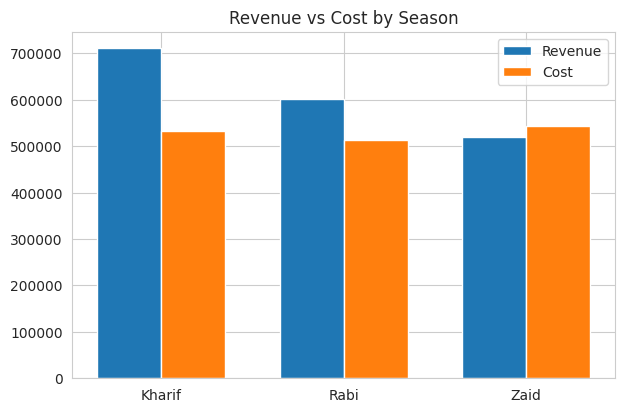

In [ ]:
fs = df.groupby("Season", observed=True)[["Revenue_INR","Total_Cost_INR"]].mean().reindex(SEASON_ORDER)
x = np.arange(3); w = 0.35
fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(x-w/2, fs["Revenue_INR"], w, label="Revenue")
ax.bar(x+w/2, fs["Total_Cost_INR"], w, label="Cost")
ax.set_xticks(x); ax.set_xticklabels(SEASON_ORDER); ax.legend()
ax.set_title("Revenue vs Cost by Season")
save(fig, "q2b_revenue_cost.png"); plt.show()

*Revenue falls faster than cost from Kharif to Zaid, driving the profit drop.*

**Q3. Environmental Conditions by Season**
Three side-by-side boxplots: rainfall, temperature and humidity by season.

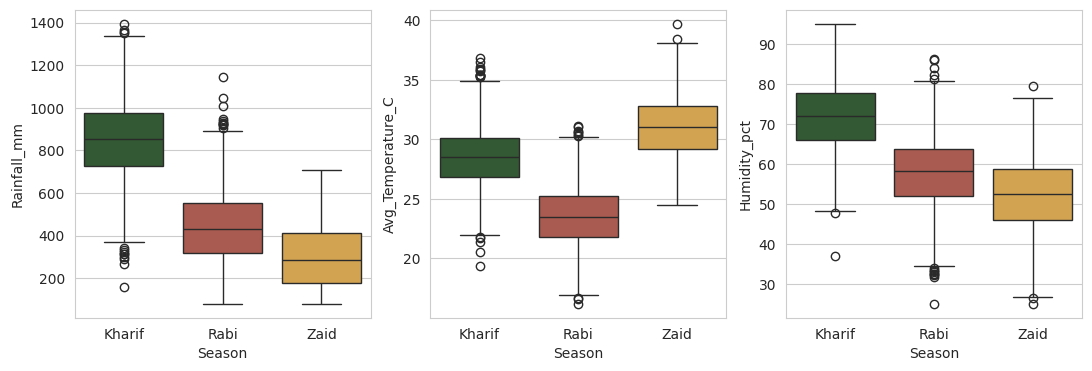

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(13,4))
for ax, col in zip(axes, ["Rainfall_mm","Avg_Temperature_C","Humidity_pct"]):
    sns.boxplot(x="Season", y=col, data=df, order=SEASON_ORDER, palette=PALETTE, ax=ax)
save(fig, "q3_env.png"); plt.show()

*Kharif = wettest/most humid. Zaid = hottest/driest.*

**Q4. Water Usage by Season**
Bar chart of average irrigation water used (m3) per season.

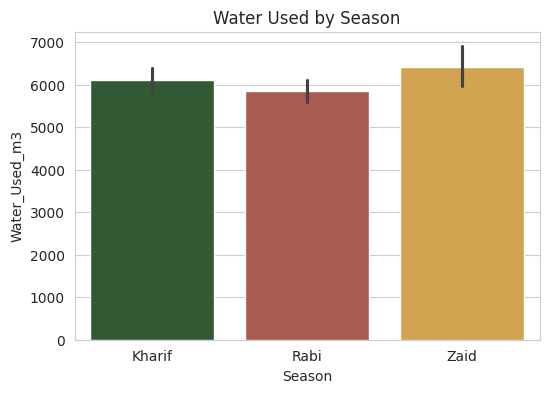

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x="Season", y="Water_Used_m3", data=df, order=SEASON_ORDER, palette=PALETTE, errorbar=("ci",95), ax=ax)
ax.set_title("Water Used by Season")
save(fig, "q4_water.png"); plt.show()

*Zaid uses the most water despite the lowest yield.*

**Q5. Rainfall vs Yield**
Scatter plot of rainfall against yield, coloured by season, plus a Spearman correlation.

rho=0.13, p=1.02e-16


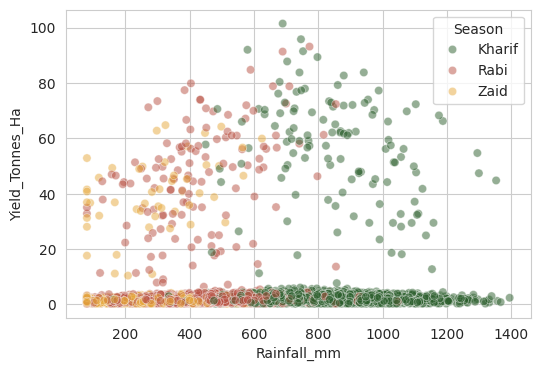

In [ ]:
r_rain, p_rain = stats.spearmanr(df["Rainfall_mm"], df["Yield_Tonnes_Ha"])
print(f"rho={r_rain:.2f}, p={p_rain:.3g}")
fig, ax = plt.subplots(figsize=(6,4))
sns.scatterplot(x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season", hue_order=SEASON_ORDER, palette=PALETTE, data=df, alpha=0.5, ax=ax)
save(fig, "q5_rain_yield.png"); plt.show()

*Weak but statistically significant positive correlation.*

**Q6. Fertilizer vs Yield**
Scatter plot of fertilizer usage against yield, coloured by season, plus a Spearman correlation.

rho=0.00, p=0.846


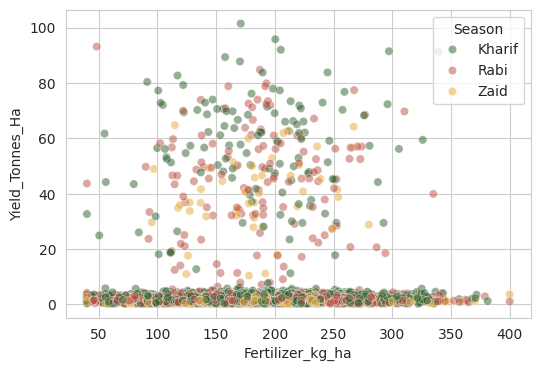

In [ ]:
r_fert, p_fert = stats.spearmanr(df["Fertilizer_kg_ha"], df["Yield_Tonnes_Ha"])
print(f"rho={r_fert:.2f}, p={p_fert:.3g}")
fig, ax = plt.subplots(figsize=(6,4))
sns.scatterplot(x="Fertilizer_kg_ha", y="Yield_Tonnes_Ha", hue="Season", hue_order=SEASON_ORDER, palette=PALETTE, data=df, alpha=0.5, ax=ax)
save(fig, "q6_fert_yield.png"); plt.show()

*No meaningful correlation.*

**Q7. Yield by Crop and Season**
Heatmap: rows = crop, columns = season, values = average yield (t/ha).

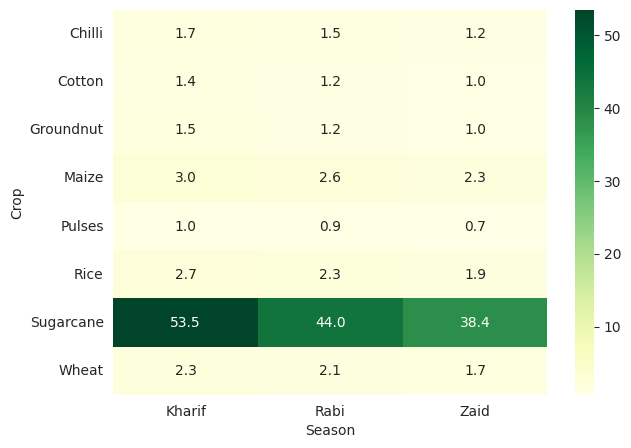

In [ ]:
crop_season = df.pivot_table(values="Yield_Tonnes_Ha", index="Crop", columns="Season", aggfunc="mean", observed=True)
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(crop_season, annot=True, fmt=".1f", cmap="YlGn", ax=ax)
save(fig, "q7_crop_season.png"); plt.show()

*Kharif > Rabi > Zaid holds for every crop.*

**Q7b. Profit by Crop and Season**
Heatmap: rows = crop, columns = season, values = average profit (INR).

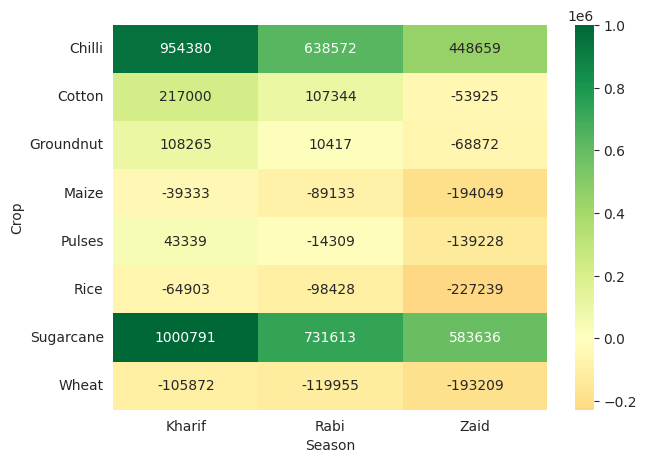

In [ ]:
crop_profit = df.pivot_table(values="Profit_INR", index="Crop", columns="Season", aggfunc="mean", observed=True).reindex(columns=SEASON_ORDER)
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(crop_profit, annot=True, fmt=".0f", cmap="RdYlGn", center=0, ax=ax)
save(fig, "q7b_crop_profit.png"); plt.show()

*Same crops can flip from profit to loss depending on season.*

**Q8. Profit by State and Season**
Heatmap: rows = state, columns = season, values = average profit (INR).

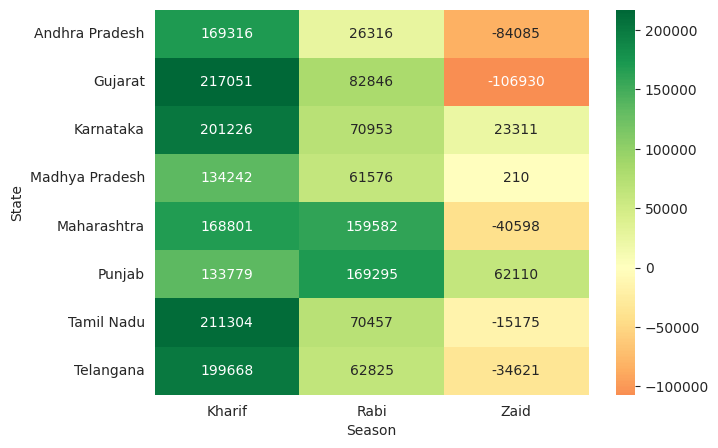

In [ ]:
state_season = df.pivot_table(values="Profit_INR", index="State", columns="Season", aggfunc="mean", observed=True)
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(state_season, annot=True, fmt=".0f", cmap="RdYlGn", center=0, ax=ax)
save(fig, "q8_state_season.png"); plt.show()

*Zaid is loss-making in most states.*

**Q9. Disease/Pest Risk by Season**
Bar chart of average disease/pest risk (%) per season, plus a Spearman correlation with humidity.

rho=0.55, p=1.82e-317


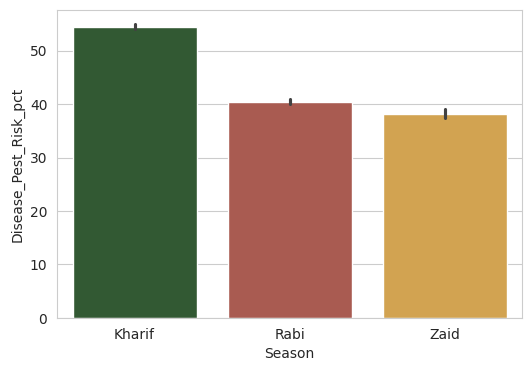

In [ ]:
r_hum, p_hum = stats.spearmanr(df["Humidity_pct"], df["Disease_Pest_Risk_pct"])
print(f"rho={r_hum:.2f}, p={p_hum:.3g}")
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x="Season", y="Disease_Pest_Risk_pct", data=df, order=SEASON_ORDER, palette=PALETTE, errorbar=("ci",95), ax=ax)
save(fig, "q9_disease.png"); plt.show()

*Humidity correlates with disease/pest risk; Kharif is the highest-risk season.*

**Q10. Loss-Making Farms by Season**
Bar chart of the percentage of farms with negative profit, per season.

Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: Is_Profitable, dtype: float64


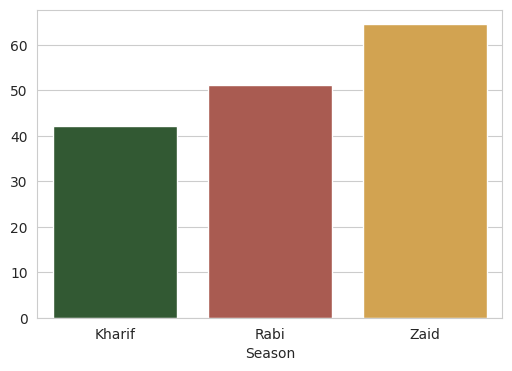

In [ ]:
loss_pct = (1 - df.groupby("Season", observed=True)["Is_Profitable"].mean()) * 100
loss_pct = loss_pct.reindex(SEASON_ORDER)
print(loss_pct.round(1))
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x=loss_pct.index, y=loss_pct.values, palette=PALETTE, ax=ax)
save(fig, "q10_loss.png"); plt.show()

*Loss share rises sharply from Kharif to Zaid.*

**Q10b. Profit Margin by Season**
Bar chart of average profit margin (% of revenue) per season, with a zero-line for reference.

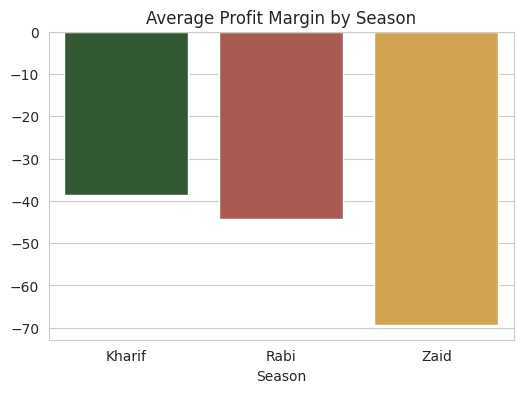

In [ ]:
margin = df.groupby("Season", observed=True)["Profit_Margin_pct"].mean().reindex(SEASON_ORDER)
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x=margin.index, y=margin.values, palette=PALETTE, ax=ax)
ax.axhline(0, color="grey", ls="--")
ax.set_title("Average Profit Margin by Season")
save(fig, "q10b_margin.png"); plt.show()

*Zaid's margin is negative on average.*

## 9. Statistical Tests
Each test prints its key statistic and p-value only.

In [ ]:
# Kruskal-Wallis: Yield ~ Season (non-parametric, since Shapiro-Wilk rejects normality)
groups = [df[df.Season==s]["Yield_Tonnes_Ha"] for s in SEASON_ORDER]
h, p = stats.kruskal(*groups)
print(f"Yield~Season: H={h:.2f}, p={p:.3g}")

Yield~Season: H=70.26, p=5.52e-16


In [ ]:
# Kruskal-Wallis: Profit ~ Season
groups = [df[df.Season==s]["Profit_INR"] for s in SEASON_ORDER]
h, p = stats.kruskal(*groups)
print(f"Profit~Season: H={h:.2f}, p={p:.3g}")

Profit~Season: H=101.93, p=7.36e-23


In [ ]:
# Mann-Whitney U: Yield, Kharif vs Rabi
u, p = stats.mannwhitneyu(df[df.Season=="Kharif"]["Yield_Tonnes_Ha"], df[df.Season=="Rabi"]["Yield_Tonnes_Ha"])
print(f"Kharif vs Rabi Yield: p={p:.3g}")

Kharif vs Rabi Yield: p=3.47e-07


In [ ]:
# Chi-square: Season vs Irrigation Method
chi2, p, dof, exp = stats.chi2_contingency(pd.crosstab(df.Season, df.Irrigation_Method))
print(f"Season vs Irrigation: chi2={chi2:.2f}, p={p:.3g}")

Season vs Irrigation: chi2=3.51, p=0.742


**Summary:**
- Yield and Profit differ significantly by season (p<0.001 both).
- Kharif vs Rabi yield differs significantly (p<0.001).
- Rainfall–Yield: weak positive (rho=0.13, p<0.001). Fertilizer–Yield: not significant.
- Humidity–Disease Risk: moderate positive (rho=0.55, p<0.001).
- Season vs Irrigation Method: **not** significant (p=0.74) — honest null result.

**Correlation Heatmap**
Heatmap of Spearman correlations between rainfall, temperature, humidity, fertilizer, water, yield, revenue and profit.

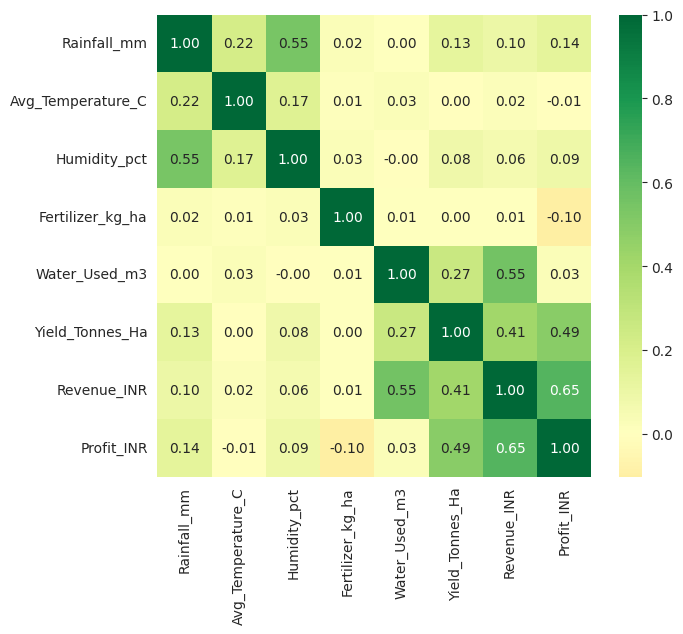

In [ ]:
cols = ["Rainfall_mm","Avg_Temperature_C","Humidity_pct","Fertilizer_kg_ha","Water_Used_m3","Yield_Tonnes_Ha","Revenue_INR","Profit_INR"]
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(df[cols].corr(method="spearman"), annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=ax)
save(fig, "corr_heatmap.png"); plt.show()

## 10. Key Findings
- Kharif is the strongest season (highest yield & profit); Zaid is the weakest (negative avg. profit, 65% of farms loss-making).
- Pattern holds across every crop and most states.
- Rainfall and humidity are linked to yield and disease risk; fertilizer usage is not.
- Season and irrigation method are not significantly related.

## 11. Recommendations
- Prioritize Kharif-season cropping where feasible.
- Review Zaid-season crop choice and irrigation cost before committing.
- Don't assume more fertilizer raises yield — check soil nutrients instead.
- Plan pest control around humid (Kharif) conditions.
- Apply state-specific rather than blanket Zaid policy.

## 12. Limitations
- No year/date column — can't separate year effects from season effects.
- Some district names repeat across states (data-quality issue).
- Correlations shown are associations, not proof of causation.
- A few Crop×Season×State groups have small sample sizes.

## 13. Conclusion
Kharif consistently outperforms Rabi and Zaid on yield and profit; Zaid is the weakest and often loss-making. These
differences are statistically significant and consistent across crops and states, supporting more informed, season-aware
agricultural planning.